# Traffic Accidents Dataset: Full EDA

This notebook performs a complete exploratory data analysis (EDA) on `data/traffic_accidents.csv`.

## Goals
- Understand dataset structure and data quality.
- Summarize numeric and categorical variables.
- Explore temporal crash patterns.
- Analyze injury severity and potential contributing factors.
- Prepare an analysis-ready cleaned dataframe for downstream modeling/reporting.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 120)
sns.set_theme(style='whitegrid', context='notebook')

RANDOM_STATE = 42

In [3]:
# Load data
file_path = 'data/traffic_accidents.csv'
df = pd.read_csv(file_path)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Shape: 209,306 rows x 24 columns


,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,intersection_related_i,damage,prim_contributory_cause,num_units,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,Y,"$501 - $1,500",UNABLE TO DETERMINE,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,Y,"OVER $1,500",IMPROPER TURNING/NO SIGNAL,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,Y,"$501 - $1,500",FOLLOWING TOO CLOSELY,3,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,Y,"OVER $1,500",UNABLE TO DETERMINE,2,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,Y,"$501 - $1,500",DRIVING SKILLS/KNOWLEDGE/EXPERIENCE,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [4]:
# Quick structural overview
print('Column types:')
print(df.dtypes)

print()
print('DataFrame info:')
df.info()

Column types:
crash_date                        object
traffic_control_device            object
weather_condition                 object
lighting_condition                object
first_crash_type                  object
trafficway_type                   object
alignment                         object
roadway_surface_cond              object
road_defect                       object
crash_type                        object
intersection_related_i            object
damage                            object
prim_contributory_cause           object
num_units                          int64
most_severe_injury                object
injuries_total                   float64
injuries_fatal                   float64
injuries_incapacitating          float64
injuries_non_incapacitating      float64
injuries_reported_not_evident    float64
injuries_no_indication           float64
crash_hour                         int64
crash_day_of_week                  int64
crash_month                        int64
dt

In [5]:
# Convert and derive date/time features
# Source date format example: 07/29/2023 01:00:00 PM

df['crash_datetime'] = pd.to_datetime(df['crash_date'], errors='coerce')
df['crash_year'] = df['crash_datetime'].dt.year
df['crash_day_name'] = df['crash_datetime'].dt.day_name()

date_parse_failures = df['crash_datetime'].isna().sum()
print(f'Failed datetime parses: {date_parse_failures}')

df[['crash_date', 'crash_datetime', 'crash_year', 'crash_day_name']].head()

Failed datetime parses: 0


,crash_date,crash_datetime,crash_year,crash_day_name
0,07/29/2023 01:00:00 PM,2023-07-29 13:00:00,2023,Saturday
1,08/13/2023 12:11:00 AM,2023-08-13 00:11:00,2023,Sunday
2,12/09/2021 10:30:00 AM,2021-12-09 10:30:00,2021,Thursday
3,08/09/2023 07:55:00 PM,2023-08-09 19:55:00,2023,Wednesday
4,08/19/2023 02:55:00 PM,2023-08-19 14:55:00,2023,Saturday


In [6]:
# Data quality checks
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .rename('missing_count')
      .to_frame()
)
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(2)

duplicates = df.duplicated().sum()
print(f'Total duplicate rows: {duplicates:,}')

print()
print('Top columns by missing values:')
missing.head(15)

Total duplicate rows: 31

Top columns by missing values:


,missing_count,missing_pct
crash_date,0,0.0
most_severe_injury,0,0.0
crash_year,0,0.0
crash_datetime,0,0.0
crash_month,0,0.0
crash_day_of_week,0,0.0
crash_hour,0,0.0
injuries_no_indication,0,0.0
injuries_reported_not_evident,0,0.0
injuries_non_incapacitating,0,0.0


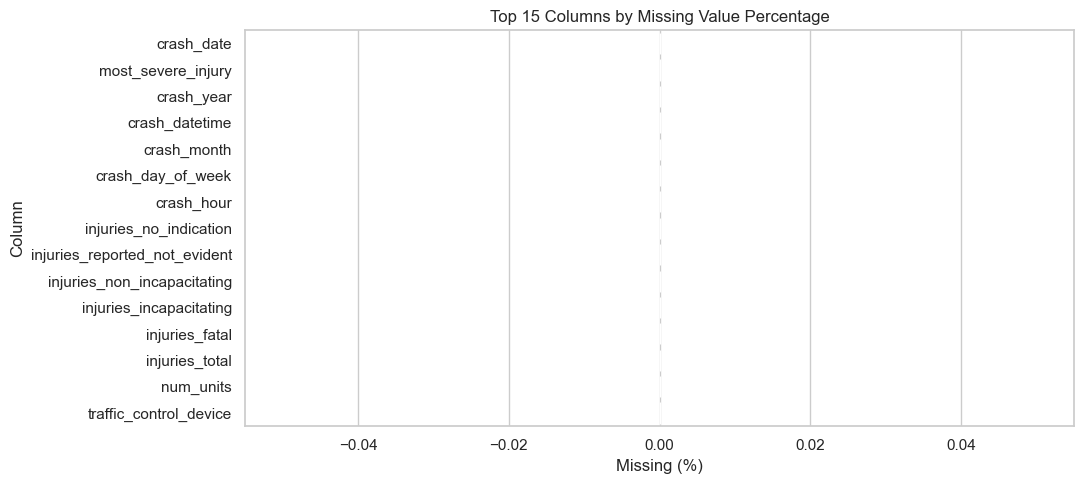

In [7]:
# Visualize missingness percentage (top 15)
missing_top = missing.head(15).reset_index().rename(columns={'index': 'column'})

plt.figure(figsize=(11, 5))
sns.barplot(data=missing_top, x='missing_pct', y='column', palette='mako')
plt.title('Top 15 Columns by Missing Value Percentage')
plt.xlabel('Missing (%)')
plt.ylabel('Column')
plt.tight_layout()
plt.show()

In [8]:
# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
category_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric columns ({len(numeric_cols)}): {numeric_cols}')
print(f'Categorical/object columns ({len(category_cols)}): {category_cols}')

# Numeric summary
if numeric_cols:
    display(df[numeric_cols].describe().T)


Numeric columns (11): ['num_units', 'injuries_total', 'injuries_fatal', 'injuries_incapacitating', 'injuries_non_incapacitating', 'injuries_reported_not_evident', 'injuries_no_indication', 'crash_hour', 'crash_day_of_week', 'crash_month', 'crash_year']
Categorical/object columns (15): ['crash_date', 'traffic_control_device', 'weather_condition', 'lighting_condition', 'first_crash_type', 'trafficway_type', 'alignment', 'roadway_surface_cond', 'road_defect', 'crash_type', 'intersection_related_i', 'damage', 'prim_contributory_cause', 'most_severe_injury', 'crash_day_name']


,count,mean,std,min,25%,50%,75%,max
num_units,209306.0,2.063300,0.396012,1.0,2.0,2.0,2.0,11.0
injuries_total,209306.0,0.382717,0.799720,0.0,0.0,0.0,1.0,21.0
injuries_fatal,209306.0,0.001859,0.047502,0.0,0.0,0.0,0.0,3.0
injuries_incapacitating,209306.0,0.038102,0.233964,0.0,0.0,0.0,0.0,7.0
injuries_non_incapacitating,209306.0,0.221241,0.614960,0.0,0.0,0.0,0.0,21.0
injuries_reported_not_evident,209306.0,0.121516,0.450865,0.0,0.0,0.0,0.0,15.0
injuries_no_indication,209306.0,2.244002,1.241175,0.0,2.0,2.0,3.0,49.0
crash_hour,209306.0,13.373047,5.603830,0.0,9.0,14.0,17.0,23.0
crash_day_of_week,209306.0,4.144024,1.966864,1.0,2.0,4.0,6.0,7.0
crash_month,209306.0,6.771822,3.427593,1.0,4.0,7.0,10.0,12.0


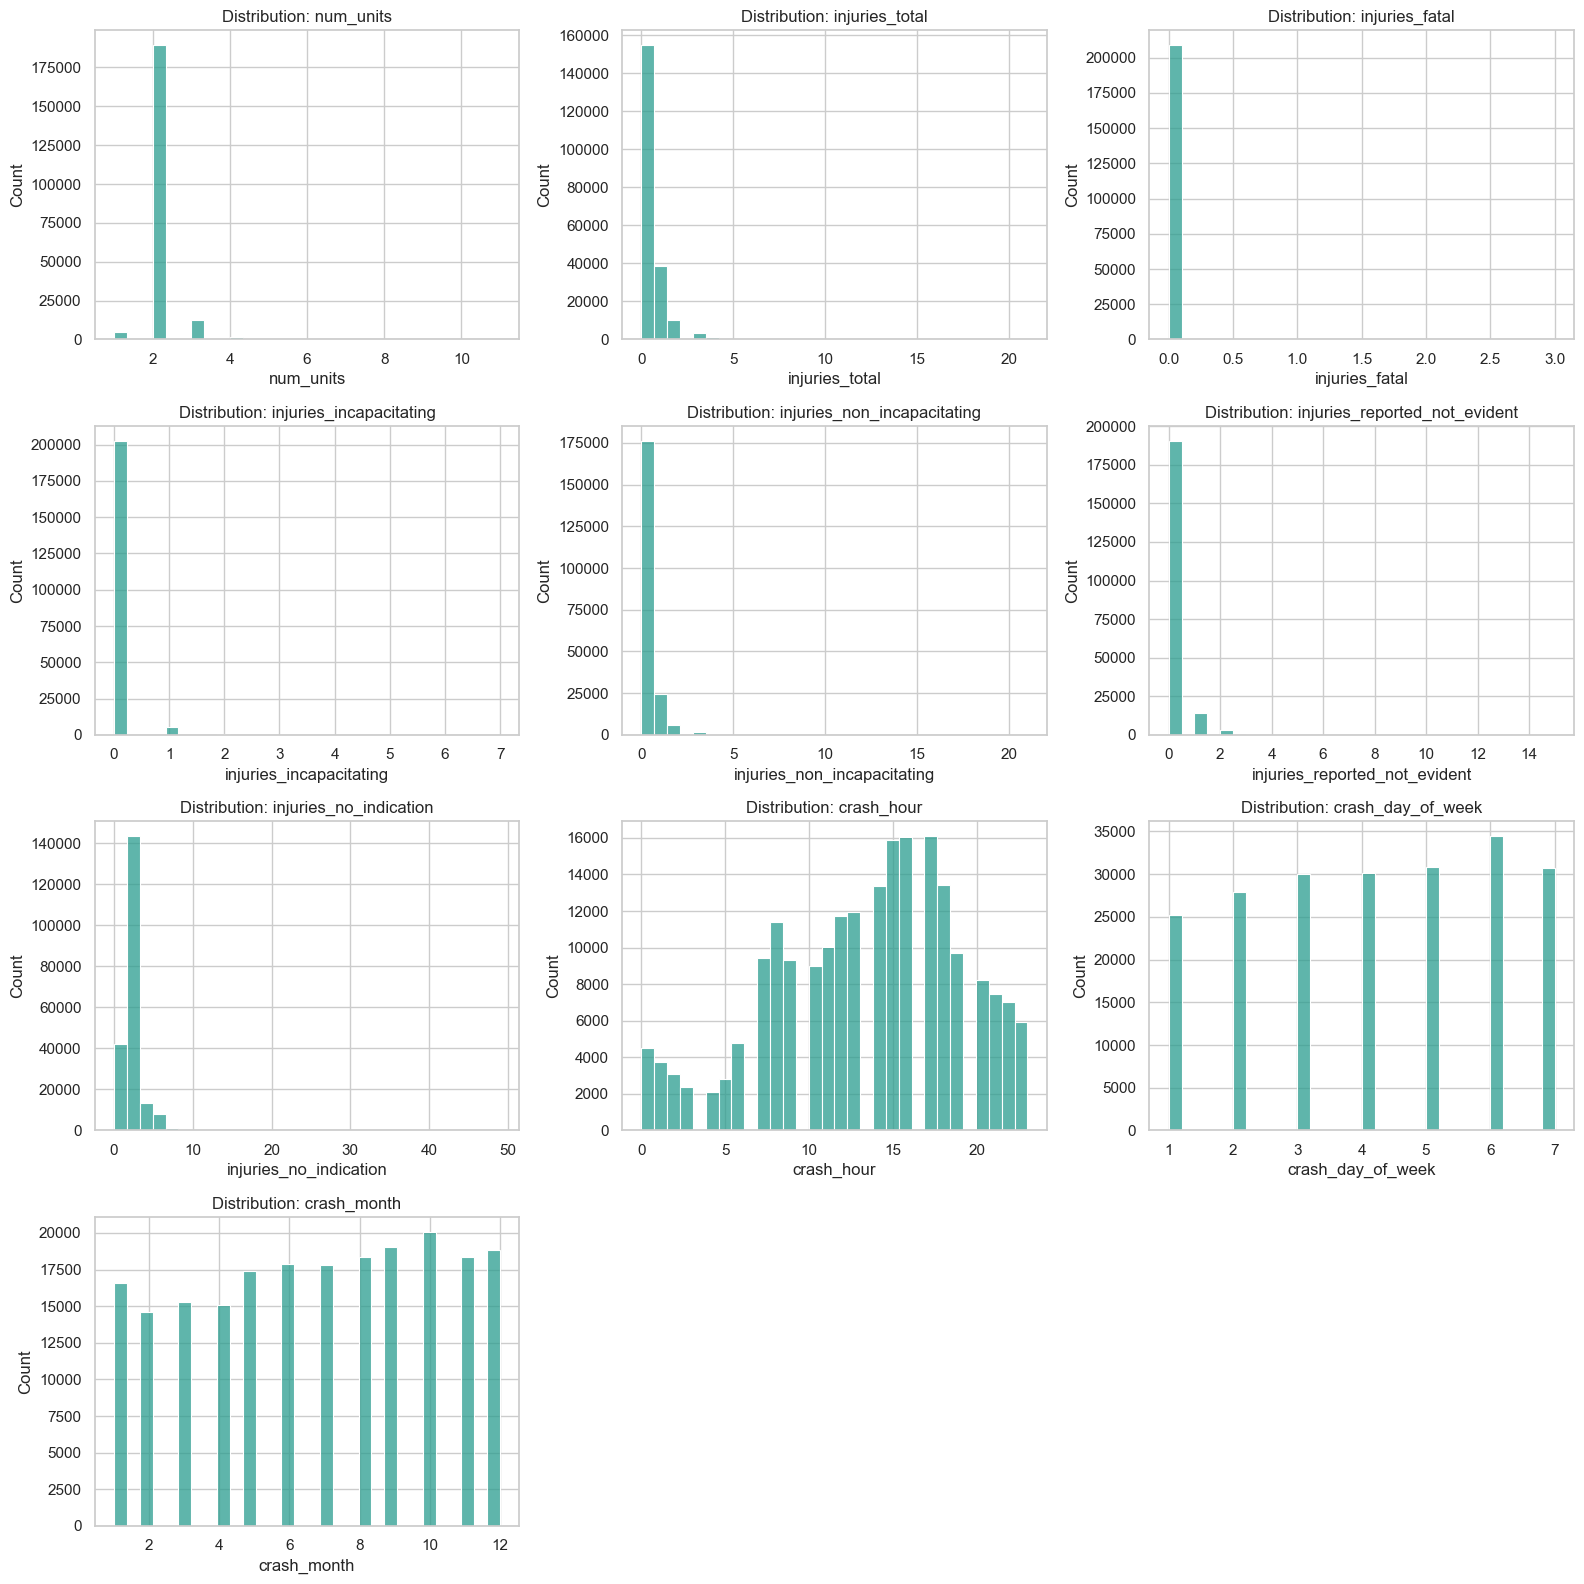

In [9]:
# Univariate distributions for key numeric fields
key_numeric = [
    'num_units', 'injuries_total', 'injuries_fatal',
    'injuries_incapacitating', 'injuries_non_incapacitating',
    'injuries_reported_not_evident', 'injuries_no_indication',
    'crash_hour', 'crash_day_of_week', 'crash_month'
]
key_numeric = [c for c in key_numeric if c in df.columns]

n = len(key_numeric)
cols = 3
rows = int(np.ceil(n / cols))

plt.figure(figsize=(16, 4 * rows))
for i, col in enumerate(key_numeric, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[col], kde=False, bins=30, color='#2a9d8f')
    plt.title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

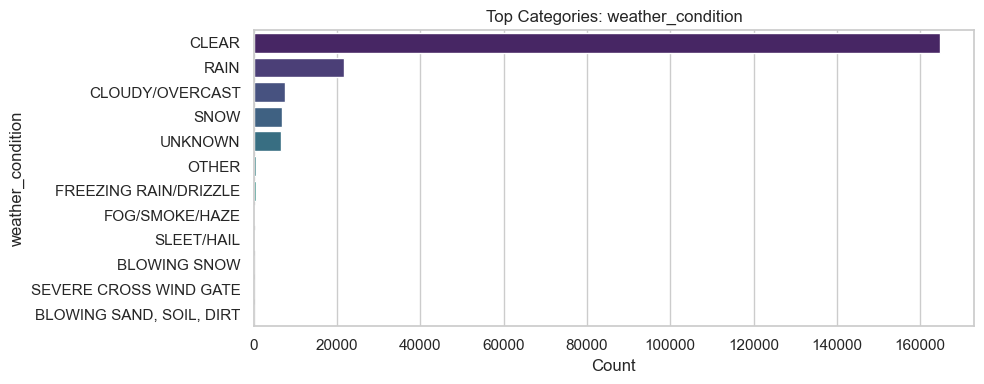

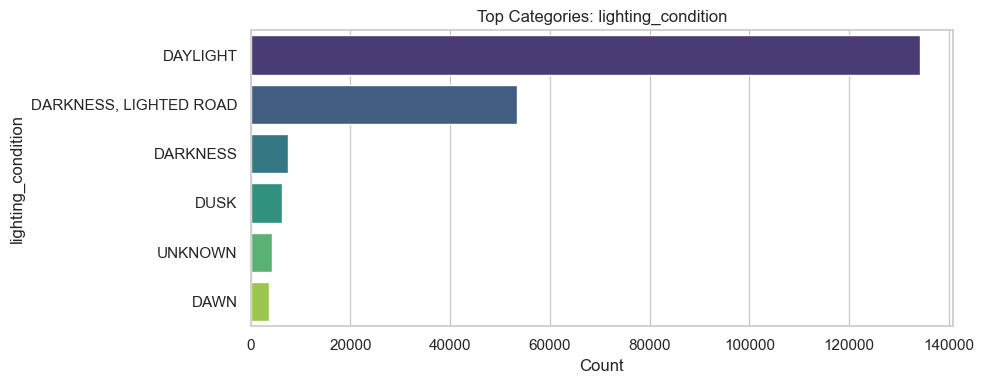

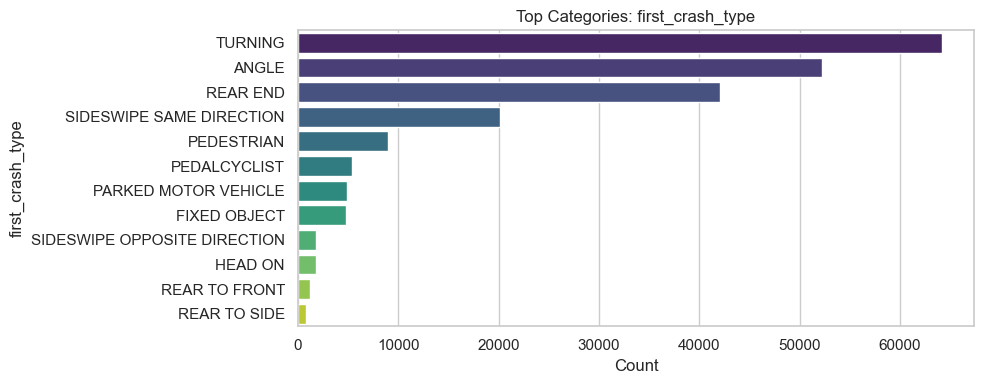

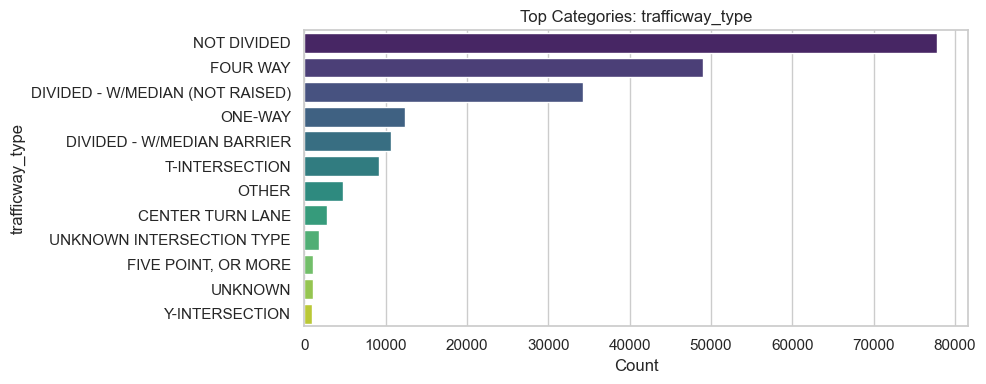

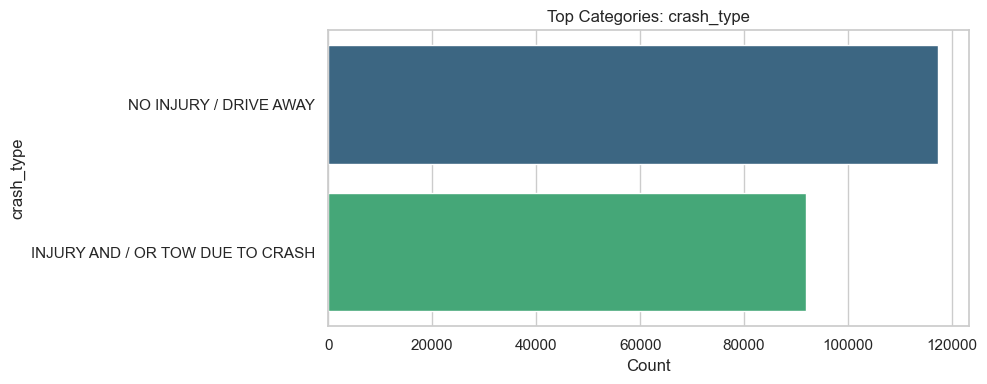

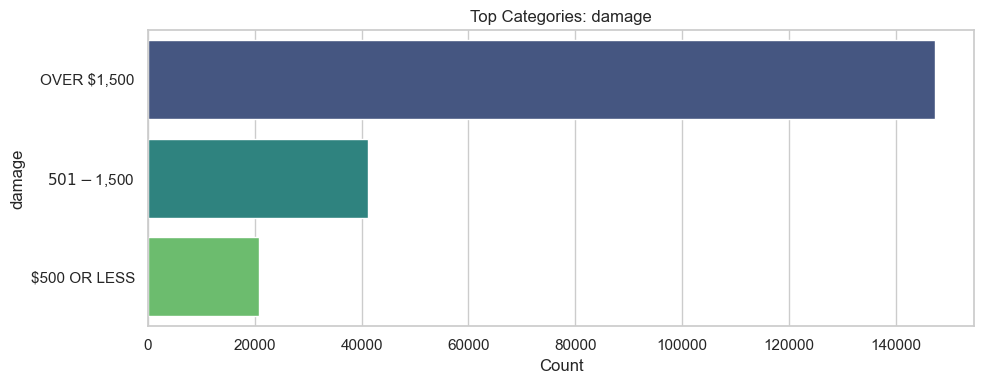

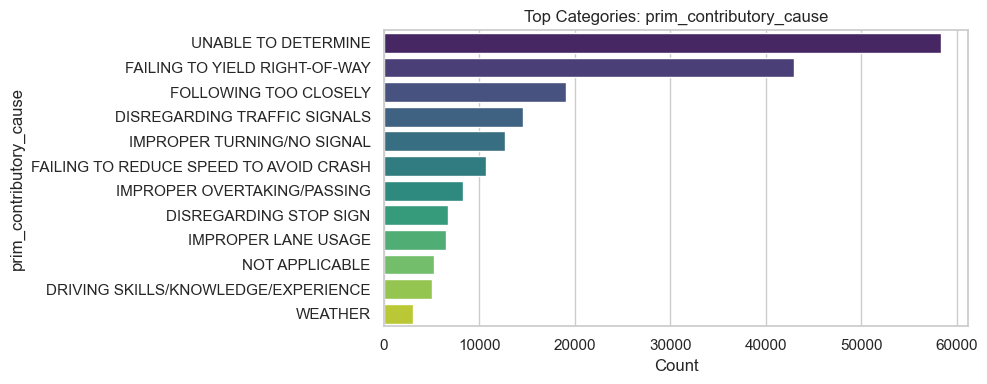

In [10]:
# Top categories for selected categorical fields
selected_cats = [
    'weather_condition', 'lighting_condition', 'first_crash_type',
    'trafficway_type', 'crash_type', 'damage', 'prim_contributory_cause'
]
selected_cats = [c for c in selected_cats if c in df.columns]

for col in selected_cats:
    plt.figure(figsize=(10, 4))
    top_counts = df[col].fillna('MISSING').value_counts().head(12)
    sns.barplot(x=top_counts.values, y=top_counts.index, palette='viridis')
    plt.title(f'Top Categories: {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

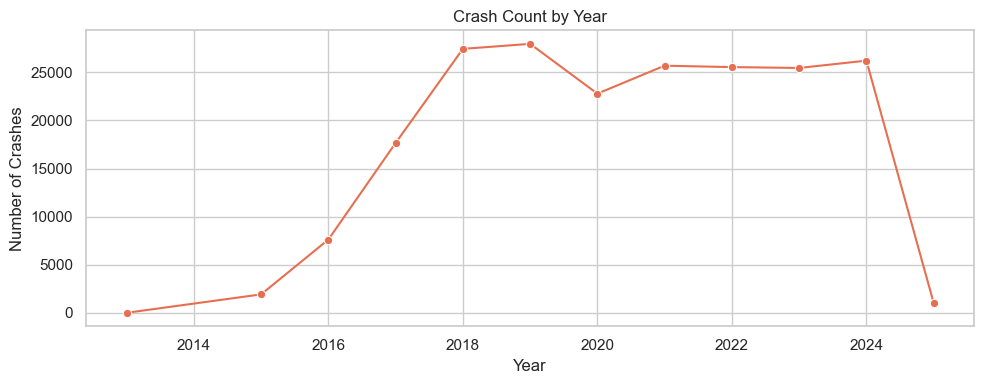

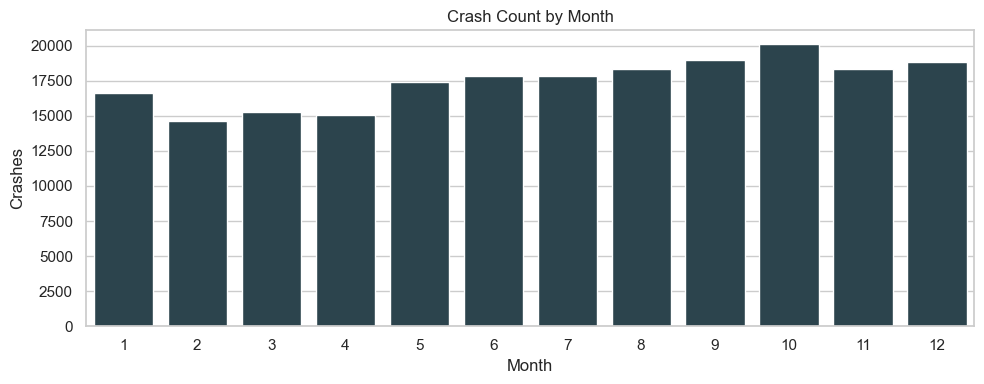

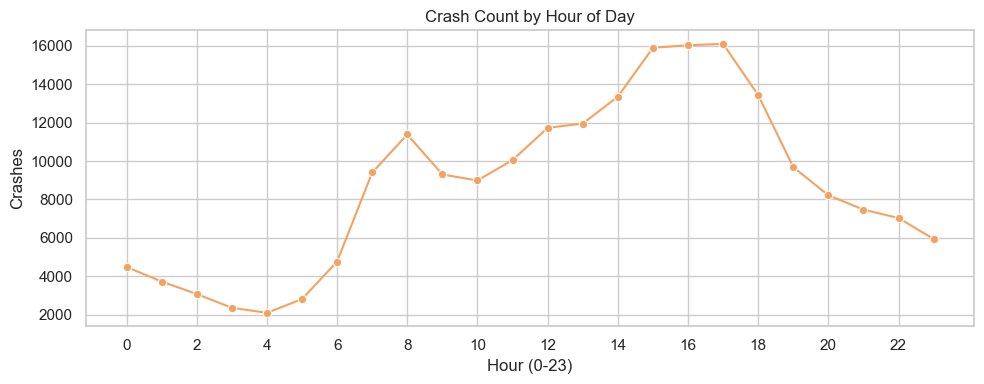

In [11]:
# Temporal trends
if 'crash_year' in df.columns:
    yearly = df['crash_year'].value_counts(dropna=True).sort_index()
    plt.figure(figsize=(10, 4))
    sns.lineplot(x=yearly.index, y=yearly.values, marker='o', color='#e76f51')
    plt.title('Crash Count by Year')
    plt.xlabel('Year')
    plt.ylabel('Number of Crashes')
    plt.tight_layout()
    plt.show()

# Crash count by month and hour
plt.figure(figsize=(10, 4))
month_counts = df['crash_month'].value_counts().sort_index()
sns.barplot(x=month_counts.index, y=month_counts.values, color='#264653')
plt.title('Crash Count by Month')
plt.xlabel('Month')
plt.ylabel('Crashes')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
hour_counts = df['crash_hour'].value_counts().sort_index()
sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker='o', color='#f4a261')
plt.title('Crash Count by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Crashes')
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

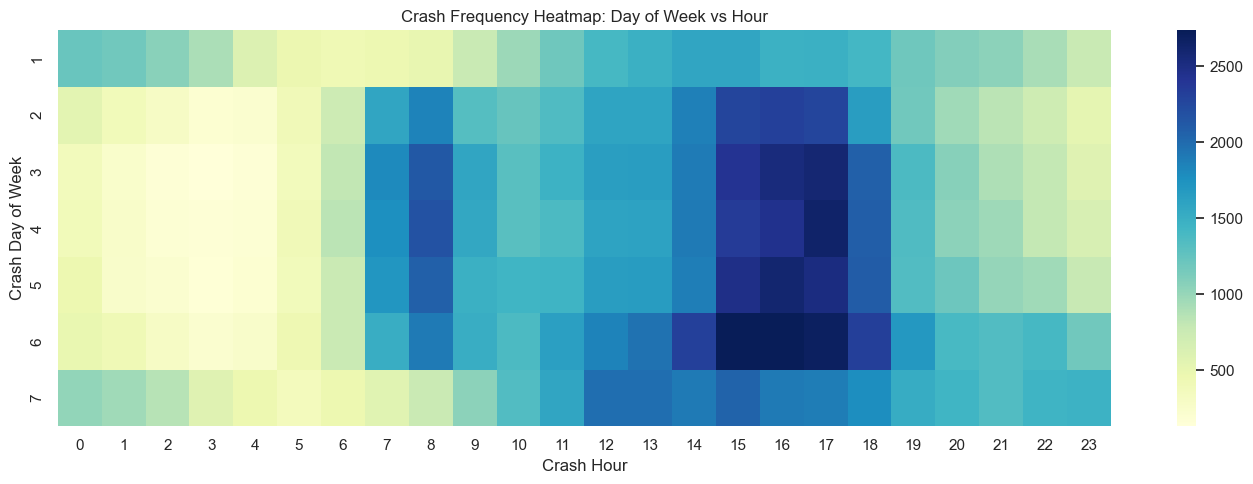

In [12]:
# Heatmap: crash volume by day-of-week and hour
# crash_day_of_week in this dataset appears numeric (1-7). We keep ordering explicit.
heat = pd.crosstab(df['crash_day_of_week'], df['crash_hour'])

plt.figure(figsize=(14, 5))
sns.heatmap(heat, cmap='YlGnBu')
plt.title('Crash Frequency Heatmap: Day of Week vs Hour')
plt.xlabel('Crash Hour')
plt.ylabel('Crash Day of Week')
plt.tight_layout()
plt.show()

In [13]:
# Injury severity analysis
injury_cols = [
    'injuries_total', 'injuries_fatal', 'injuries_incapacitating',
    'injuries_non_incapacitating', 'injuries_reported_not_evident',
    'injuries_no_indication'
]
injury_cols = [c for c in injury_cols if c in df.columns]

injury_summary = df[injury_cols].sum().sort_values(ascending=False).rename('total_cases').to_frame()
print('Total injury outcomes across all crashes:')
display(injury_summary)

# Binary target for whether any injury occurred
if 'injuries_total' in df.columns:
    df['any_injury'] = (df['injuries_total'] > 0).astype(int)
    injury_rate = df['any_injury'].mean() * 100
    print()
    print(f'Share of crashes with any injury: {injury_rate:.2f}%')

Total injury outcomes across all crashes:


,total_cases
injuries_no_indication,469683.0
injuries_total,80105.0
injuries_non_incapacitating,46307.0
injuries_reported_not_evident,25434.0
injuries_incapacitating,7975.0
injuries_fatal,389.0



Share of crashes with any injury: 26.05%


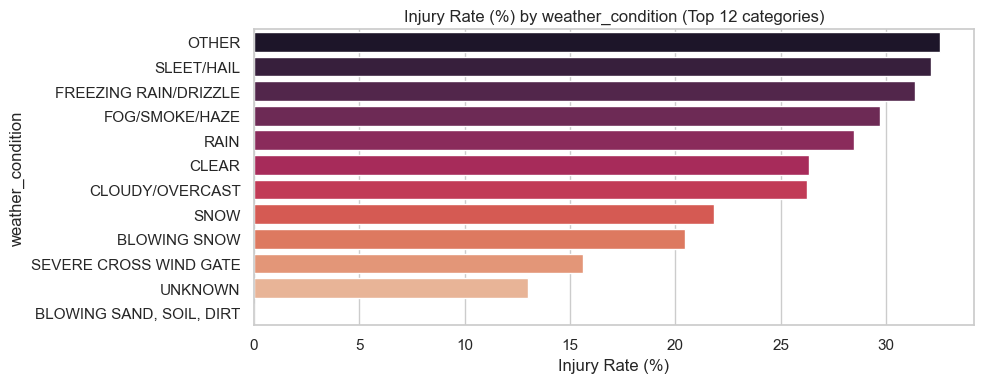

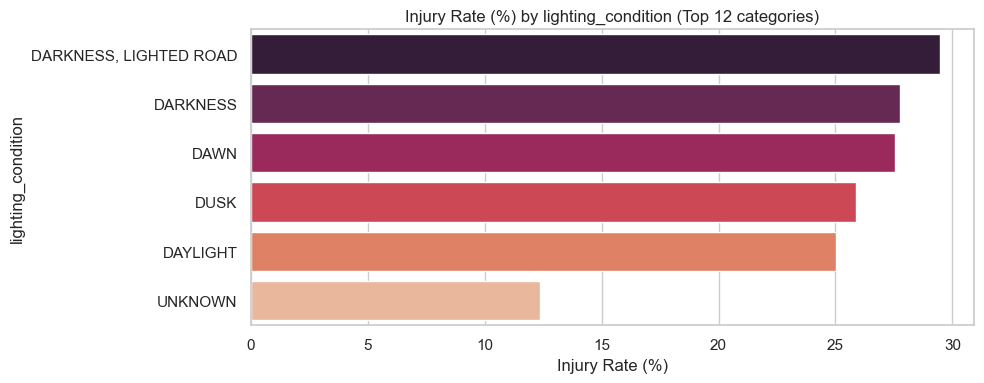

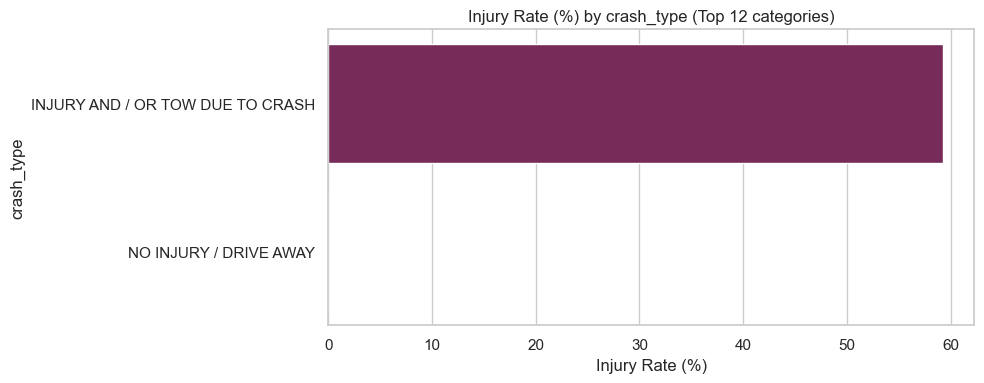

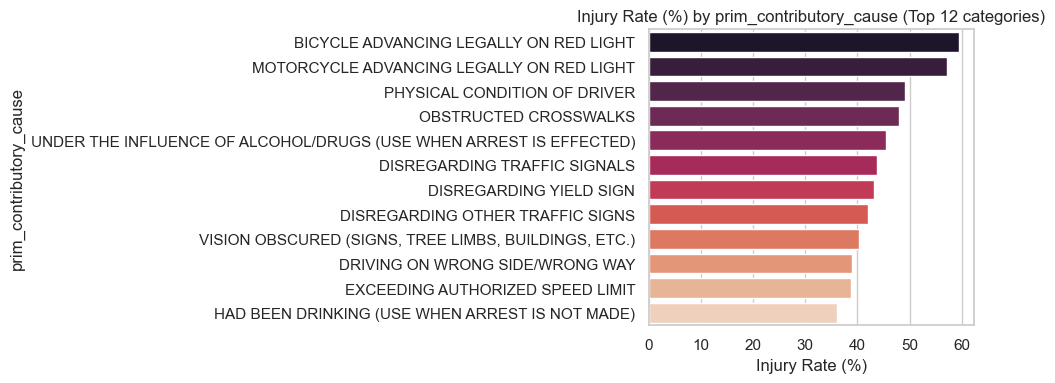

In [14]:
# Compare injury rate by selected factors
factors = ['weather_condition', 'lighting_condition', 'crash_type', 'prim_contributory_cause']
factors = [f for f in factors if f in df.columns]

for f in factors:
    grp = (
        df.groupby(f, dropna=False)['any_injury']
          .mean()
          .sort_values(ascending=False)
          .head(12)
          .mul(100)
    )

    plt.figure(figsize=(10, 4))
    sns.barplot(x=grp.values, y=grp.index, palette='rocket')
    plt.title(f'Injury Rate (%) by {f} (Top 12 categories)')
    plt.xlabel('Injury Rate (%)')
    plt.ylabel(f)
    plt.tight_layout()
    plt.show()

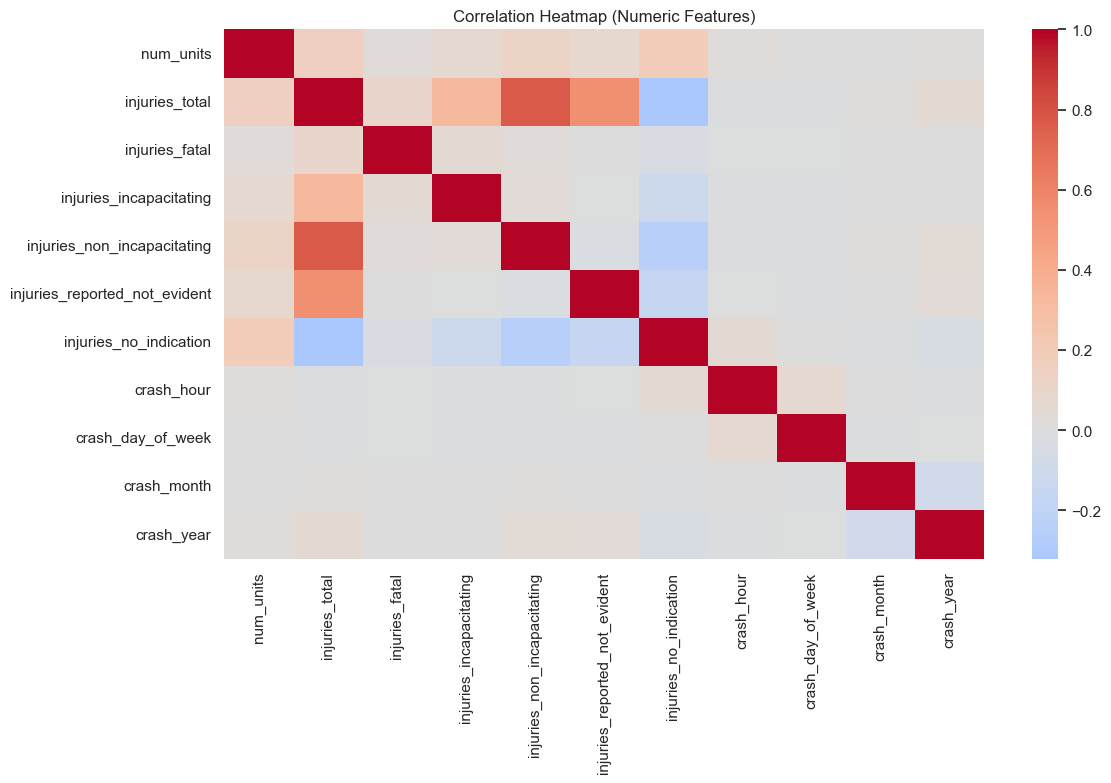

In [15]:
# Correlation among numeric variables
if len(numeric_cols) > 1:
    corr = df[numeric_cols].corr(numeric_only=True)

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap (Numeric Features)')
    plt.tight_layout()
    plt.show()

In [16]:
# Build a cleaned analysis dataframe
# Strategy:
# 1) Keep a copy of all columns.
# 2) Standardize category strings.
# 3) Keep missing values explicit for categories.

df_clean = df.copy()

for col in category_cols:
    df_clean[col] = df_clean[col].astype('string').str.strip()
    df_clean[col] = df_clean[col].fillna('MISSING')

# Optionally drop perfect duplicates
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)

print(f'Rows before de-duplication: {before:,}')
print(f'Rows after de-duplication:  {after:,}')
print(f'Removed duplicates:         {before - after:,}')

print()
print('Cleaned dataframe preview:')
display(df_clean.head())
print(f'df_clean shape: {df_clean.shape}')

Rows before de-duplication: 209,306
Rows after de-duplication:  209,275
Removed duplicates:         31

Cleaned dataframe preview:


,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,intersection_related_i,damage,prim_contributory_cause,num_units,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month,crash_datetime,crash_year,crash_day_name,any_injury
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,Y,"$501 - $1,500",UNABLE TO DETERMINE,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7,2023-07-29 13:00:00,2023,Saturday,0
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,Y,"OVER $1,500",IMPROPER TURNING/NO SIGNAL,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8,2023-08-13 00:11:00,2023,Sunday,0
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,Y,"$501 - $1,500",FOLLOWING TOO CLOSELY,3,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12,2021-12-09 10:30:00,2021,Thursday,0
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,Y,"OVER $1,500",UNABLE TO DETERMINE,2,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8,2023-08-09 19:55:00,2023,Wednesday,1
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,Y,"$501 - $1,500",DRIVING SKILLS/KNOWLEDGE/EXPERIENCE,2,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8,2023-08-19 14:55:00,2023,Saturday,0


df_clean shape: (209275, 28)


In [ ]:
# # Export cleaned dataframe to CSV
# import os
# print(os.path.abspath("cleaned_dataset.csv"))

# df_clean.to_csv("cleaned_dataset.csv", index=False)

/Users/janetlu/Documents/School materials/Master/Term5Courses/Data 552 Communication and Argumentation /Project/cleaned_dataset.csv


## EDA Outcome Summary

- A quality profile (missingness, duplicates, datatypes).
- Core univariate summaries for numeric and categorical features.
- Temporal crash patterns (year, month, hour, day-hour heatmap).
- Injury severity totals and injury-rate comparisons by key factors.
- A cleaned dataframe (`df_clean`) for analysis/modeling.
